In [75]:
import numpy as np 
import pandas as pd 
import yfinance as yf  
import matplotlib.pyplot as plt 


import torch 
import torch.nn as nn 
import torch.optim as optim 

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error 

In [76]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 

In [77]:
ticker = 'AAPL' 
df = yf.download(ticker, start='2020-01-01') 

[*********************100%***********************]  1 of 1 completed


In [78]:
df 

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800
2020-01-06,72.201431,72.239965,70.503569,70.754036,118387200
2020-01-07,71.861862,72.466345,71.642704,72.211064,108872000
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200
...,...,...,...,...,...
2026-07-14,314.859985,316.190002,311.910004,313.760010,36336800
2026-07-15,327.500000,328.730011,317.320007,317.619995,60957600


<Axes: xlabel='Date'>

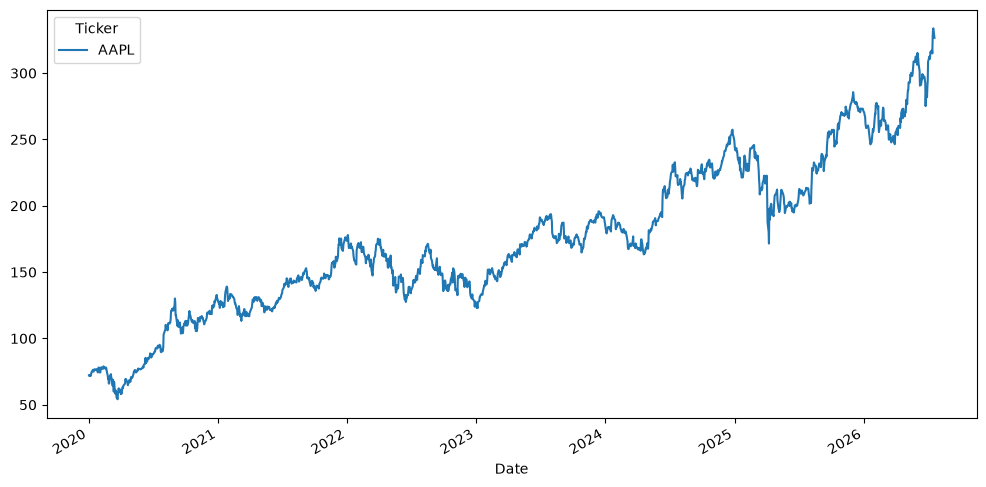

In [79]:
df.Close.plot(figsize=(12,6))

In [80]:
scaler = StandardScaler()
df['Close'] = scaler.fit_transform(df[['Close']]) 


In [81]:
df.Close

Ticker,AAPL
Date,
2020-01-02,-1.779193
2020-01-03,-1.791505
2020-01-06,-1.781512
2020-01-07,-1.787457
2020-01-08,-1.767218
...,...
2026-07-14,2.467096
2026-07-15,2.688404
2026-07-16,2.789254


In [82]:
sequence_length = 30

data = [] 

for i in range(len(df) - sequence_length):
    data.append(df['Close'].values[i:i+sequence_length])

data = np.array(data)



In [83]:
data

array([[[-1.77919276],
        [-1.79150548],
        [-1.78151157],
        ...,
        [-1.69478189],
        [-1.66270215],
        [-1.67254979]],

       [[-1.79150548],
        [-1.78151157],
        [-1.78745694],
        ...,
        [-1.66270215],
        [-1.67254979],
        [-1.67221183]],

       [[-1.78151157],
        [-1.78745694],
        [-1.76721772],
        ...,
        [-1.67254979],
        [-1.67221183],
        [-1.69736052]],

       ...,

       [[ 2.47304914],
        [ 2.3865567 ],
        [ 2.40354005],
        ...,
        [ 2.50999199],
        [ 2.46709575],
        [ 2.68840449]],

       [[ 2.3865567 ],
        [ 2.40354005],
        [ 2.33543141],
        ...,
        [ 2.46709575],
        [ 2.68840449],
        [ 2.7892541 ]],

       [[ 2.40354005],
        [ 2.33543141],
        [ 2.23388184],
        ...,
        [ 2.68840449],
        [ 2.7892541 ],
        [ 2.79765788]]], shape=(1614, 30, 1))

In [84]:
train_size = int(len(data) * 0.8)

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.FloatTensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.FloatTensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.FloatTensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.FloatTensor).to(device)

In [85]:
class PredictionModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(PredictionModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out 

In [86]:
model = PredictionModel(input_size=1, hidden_size=32, num_layers=2).to(device)

In [87]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [88]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(X_train)
    loss = criterion(y_train_pred, y_train)

    if (i+1) % 25 == 0:
        print(f'Epoch {i+1}/{num_epochs}, Loss: {loss.item():.4f}')
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


Epoch 25/200, Loss: 0.0085
Epoch 50/200, Loss: 0.0046
Epoch 75/200, Loss: 0.0040
Epoch 100/200, Loss: 0.0037
Epoch 125/200, Loss: 0.0034
Epoch 150/200, Loss: 0.0032
Epoch 175/200, Loss: 0.0031
Epoch 200/200, Loss: 0.0029


In [90]:
model.eval()

with torch.no_grad():
	y_test_pred = model(X_test)
	y_train_pred = model(X_train)

def tensor_to_numpy(x):
	return x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else x

y_train_pred = scaler.inverse_transform(tensor_to_numpy(y_train_pred))
y_test_pred = scaler.inverse_transform(tensor_to_numpy(y_test_pred))
y_train = scaler.inverse_transform(tensor_to_numpy(y_train))
y_test = scaler.inverse_transform(tensor_to_numpy(y_test))
 

AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

In [68]:
train_rmse = (root_mean_squared_error(y_train[0, :], y_train_pred[0, :]))
test_rmse = (root_mean_squared_error(y_test[0, :], y_test_pred[0, :]))


In [69]:
test_rmse, train_rmse


(21.056427001953125, 0.00098419189453125)